In [4]:
import os
import glob
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ==========================================
# 1. 이미지와 마스크 파일 경로 1:1 매칭 함수
# ==========================================
def get_image_mask_pairs(base_dir):
    image_paths = []
    mask_paths = []

    # 1번 세트와 2번 세트의 폴더 경로 정의
    data_sets = [
        {
            'img_dir': os.path.join(base_dir, r"annotation_set_1\2_original_imgs"),
            'mask_dir': os.path.join(base_dir, r"annotation_set_1\1_masked_imgs")
        },
        {
            'img_dir': os.path.join(base_dir, r"annotation_set_2\12_original_imgs"),
            'mask_dir': os.path.join(base_dir, r"annotation_set_2\11_masked_imgs")
        }
    ]

    for data_set in data_sets:
        img_dir = data_set['img_dir']
        mask_dir = data_set['mask_dir']

        # 해당 폴더 내의 모든 jpg 파일 검색
        search_pattern = os.path.join(img_dir, "*.jpg")
        for img_path in glob.glob(search_pattern):
            # 원본 파일명 추출 (예: '20201229Akihabara_out_01560.jpg')
            filename = os.path.basename(img_path)
            
            # 마스크 파일명 생성 (원본 파일명 뒤에 .json.png 추가)
            mask_filename = filename + ".json.png"
            mask_path = os.path.join(mask_dir, mask_filename)

            # 짝지은 마스크 파일이 실제로 존재하는지 확인 후 리스트에 추가
            if os.path.exists(mask_path):
                image_paths.append(img_path)
                mask_paths.append(mask_path)
            else:
                print(f"⚠️ Warning: 마스크 파일을 찾을 수 없습니다 -> {mask_path}")

    return image_paths, mask_paths

# ==========================================
# 2. 커스텀 데이터셋(Dataset) 클래스
# ==========================================
class BillboardDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 1. 이미지 로드 및 RGB 변환
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 2. 마스크 로드 (흑백 이미지로 불러오기)
        mask_path = self.mask_paths[idx]
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # 마스크 이진화 처리 (픽셀값이 0보다 크면 1(객체), 아니면 0(배경))
        # 올려주신 마스크의 간판 영역이 흰색(255)이므로 이진화가 필요합니다.
        mask = (mask > 0).astype(np.float32)

        # 3. 데이터 증강 및 텐서 변환 적용
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # 파이토치 모델 입력에 맞게 마스크 채널 차원 추가 (H, W -> 1, H, W)
        mask = mask.unsqueeze(0) if isinstance(mask, torch.Tensor) else np.expand_dims(mask, axis=0)

        return image, mask

# ==========================================
# 3. 데이터 로더 준비 및 실행 (사용 예시)
# ==========================================
# 사용자님의 최상위 데이터 폴더 경로
BASE_DIR = r"C:\Users\Administrator\Desktop\train\archive"

# 1. 이미지와 마스크 짝짓기
all_images, all_masks = get_image_mask_pairs(BASE_DIR)
print(f"총 {len(all_images)}개의 데이터 쌍(Pair)을 찾았습니다.")

# 2. Train / Validation 분리 (8:2 비율)
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    all_images, all_masks, test_size=0.2, random_state=42
)

# 3. Transform (데이터 증강 및 크기 조절) 정의
train_transform = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), # ImageNet 기준 정규화
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# 4. 데이터셋 및 데이터로더 생성
train_dataset = BillboardDataset(train_imgs, train_masks, transform=train_transform)
val_dataset = BillboardDataset(val_imgs, val_masks, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

print(f"Train 배치 개수: {len(train_loader)}, Val 배치 개수: {len(val_loader)}")

# IoU 점수를 계산하는 함수 정의 (이 부분을 학습 루프 위에 추가하세요)
def iou_score(pred, target, threshold=0.5):
    # 모델의 출력이 sigmoid를 거쳤으므로 바로 threshold와 비교
    pred = (pred > threshold).float()
    target = target.float()
    
    # 교집합과 합집합 계산
    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) - intersection
    
    # IoU = 교집합 / 합집합 (0으로 나누기 방지)
    return ((intersection + 1e-6) / (union + 1e-6)).mean().item()





총 4143개의 데이터 쌍(Pair)을 찾았습니다.
Train 배치 개수: 415, Val 배치 개수: 104


In [5]:
import torch
import segmentation_models_pytorch as smp
from tqdm import tqdm

# 1. 초기 설정 및 모델 정의
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"DEVICE: {DEVICE}")

model = smp.DeepLabV3Plus(
    encoder_name='resnet50',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation='sigmoid'
).to(DEVICE)

# 올바른 손실 함수 설정 (이중 시그모이드 버그 차단)
loss_fn = smp.losses.DiceLoss(mode='binary', from_logits=False) 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# 2. 학습 곡선 기록을 위한 리스트 선언
history = {
    'train_loss': [],
    'val_loss': [],
    'val_iou': []
}

EPOCHS = 40
best_iou = 0.0
SAVE_PATH = 'best_model_deeplabv3plus_resnet50.pth'

print(f"Starting Training: {EPOCHS} Epochs")
for epoch in range(1, EPOCHS + 1):
    # --- [1. Training Phase] ---
    model.train()
    epoch_train_loss = 0
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]")
    
    for imgs, masks in train_pbar:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        
        optimizer.zero_grad()
        preds = model(imgs)
        loss = loss_fn(preds, masks)
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()
        train_pbar.set_postfix(loss=f"{loss.item():.4f}")

    # --- [2. Validation Phase] ---
    model.eval()
    epoch_val_loss = 0
    epoch_val_iou = 0
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False)
    
    with torch.no_grad():
        for imgs, masks in val_pbar:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            
            preds = model(imgs)
            v_loss = loss_fn(preds, masks).item()
            epoch_val_loss += v_loss
            
            iou = iou_score(preds, masks)
            epoch_val_iou += iou
            
            val_pbar.set_postfix(loss=f"{v_loss:.4f}", iou=f"{iou*100:.2f}%")
    
    # 에포크 평균치 계산
    avg_train_loss = epoch_train_loss / len(train_loader)
    avg_val_loss = epoch_val_loss / len(val_loader)
    avg_val_iou = epoch_val_iou / len(val_loader)
    
    # 역사(History) 기록 배열에 저장
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_iou'].append(avg_val_iou)
    
    print(f"✨ Epoch {epoch:02d} 요약 | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val IoU: {avg_val_iou*100:.2f}%")
    
    # 최고 점수 모델 저장
    if avg_val_iou > best_iou:
        best_iou = avg_val_iou
        torch.save(model, SAVE_PATH)
        print(f"   ✅ 최고 점수 갱신! 모델 저장 완료 (Best IoU: {best_iou*100:.2f}%)")
    print("-" * 60)

print(f"\n🎉 모든 학습 완료. 최종 Best IoU: {best_iou*100:.2f}%")

DEVICE: cuda
Starting Training: 40 Epochs


Epoch 1/40 [Train]: 100%|██████████| 415/415 [09:12<00:00,  1.33s/it, loss=0.3387]


✨ Epoch 01 요약 | Train Loss: 0.5553 | Val Loss: 0.3802 | Val IoU: 44.89%
   ✅ 최고 점수 갱신! 모델 저장 완료 (Best IoU: 44.89%)
------------------------------------------------------------


Epoch 2/40 [Train]: 100%|██████████| 415/415 [08:51<00:00,  1.28s/it, loss=0.4163]


✨ Epoch 02 요약 | Train Loss: 0.3390 | Val Loss: 0.3015 | Val IoU: 51.75%
   ✅ 최고 점수 갱신! 모델 저장 완료 (Best IoU: 51.75%)
------------------------------------------------------------


...

✨ Epoch 12 요약 | Train Loss: 0.1539 | Val Loss: 0.2161 | Val IoU: 62.60%
------------------------------------------------------------


Epoch 13/40 [Train]: 100%|██████████| 415/415 [07:16<00:00,  1.05s/it, loss=0.3814]


✨ Epoch 13 요약 | Train Loss: 0.1508 | Val Loss: 0.2153 | Val IoU: 63.22%
------------------------------------------------------------


Epoch 14/40 [Train]:   6%|▌         | 23/415 [00:24<06:54,  1.06s/it, loss=0.2033]


KeyboardInterrupt: 

📢 학습 수치 기록 데이터('learning_history.csv') 저장 완료!
📢 학습 곡선 그래프 이미지('learning_curves.png') 저장 완료!


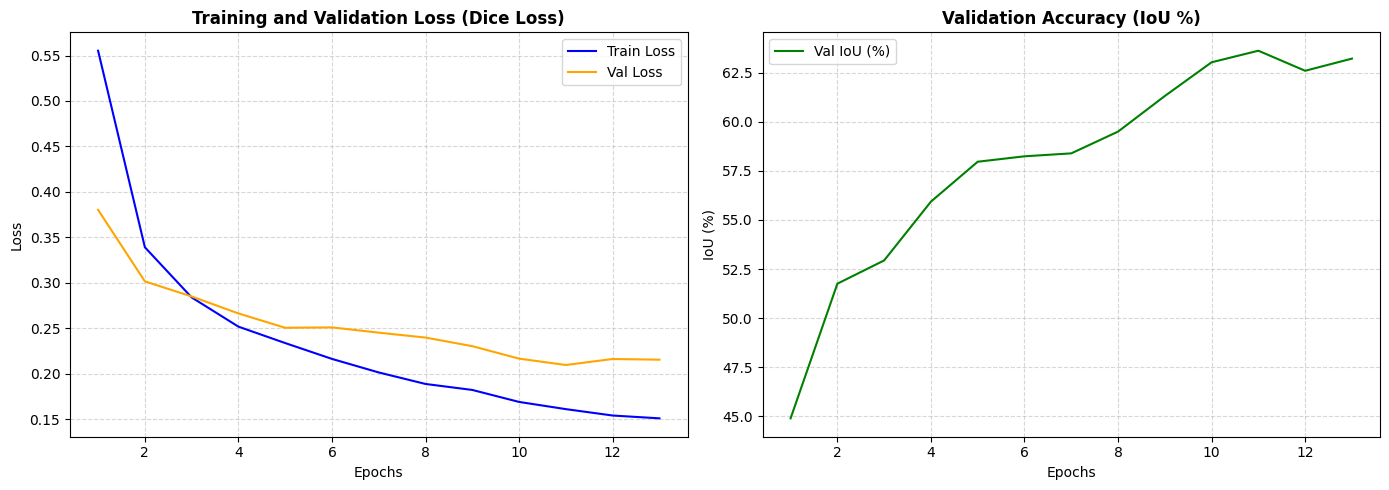

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 학습 수치 데이터 파일(.csv)로 내보내기
history_df = pd.DataFrame({
    'Epoch': range(1, len(history['train_loss']) + 1),
    'Train_Loss': history['train_loss'],
    'Val_Loss': history['val_loss'],
    'Val_IoU_Percent': [iou * 100 for iou in history['val_iou']]
})
history_df.to_csv('learning_history.csv', index=False)
print("📢 학습 수치 기록 데이터('learning_history.csv') 저장 완료!")

# 2. 학습 곡선 시각화
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# 왼쪽 그래프: 손실 함수
plt.subplot(1, 2, 1)
# fontdict 제거
plt.plot(epochs_range, history['train_loss'], label='Train Loss', color='blue')
plt.plot(epochs_range, history['val_loss'], label='Val Loss', color='orange')
plt.title('Training and Validation Loss (Dice Loss)', fontdict={'weight': 'bold'}) # 제목에는 사용 가능
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# 오른쪽 그래프: 정확도
plt.subplot(1, 2, 2)
val_iou_percent = [iou * 100 for iou in history['val_iou']]
# fontdict 제거
plt.plot(epochs_range, val_iou_percent, label='Val IoU (%)', color='green')
plt.title('Validation Accuracy (IoU %)', fontdict={'weight': 'bold'}) # 제목에는 사용 가능
plt.xlabel('Epochs')
plt.ylabel('IoU (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=300)
print("📢 학습 곡선 그래프 이미지('learning_curves.png') 저장 완료!")
plt.show()